# Task 3 - Python Data Processing and Analytics
### CP60056E Databases and Analytics - NorthStar Case Study

> Runtime: Python 3 (default in Colab)

Covers data loading, cleaning, feature engineering, and visualisation using pandas, NumPy, Matplotlib, and Seaborn.

In [ ]:
!pip install seaborn -q

In [ ]:
DATA_PATH = '/content/'
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns, warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
customers  = pd.read_csv(DATA_PATH+'customers.csv')
orders     = pd.read_csv(DATA_PATH+'orders.csv')
deliveries = pd.read_csv(DATA_PATH+'deliveries.csv')
complaints = pd.read_csv(DATA_PATH+'complaints.csv')
drivers    = pd.read_csv(DATA_PATH+'drivers.csv')
hubs       = pd.read_csv(DATA_PATH+'hubs.csv')
vehicles   = pd.read_csv(DATA_PATH+'vehicles.csv')
incidents  = pd.read_csv(DATA_PATH+'incidents.csv')
app_events = pd.read_csv(DATA_PATH+'app_events.csv')
for df in [orders,deliveries,customers,drivers,vehicles,app_events]:
    for col in df.columns:
        if 'zone' in col.lower(): df[col] = df[col].str.strip().str.title()
orders['order_created_at'] = pd.to_datetime(orders['order_created_at'], errors='coerce')
deliveries['dispatch_time'] = pd.to_datetime(deliveries['dispatch_time'], errors='coerce')
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'], errors='coerce')
complaints['created_at'] = pd.to_datetime(complaints['created_at'], errors='coerce')
deliveries['actual_duration_hrs'] = (deliveries['delivery_completed_at']-deliveries['dispatch_time']).dt.total_seconds()/3600
ops = deliveries.merge(orders,on='order_id',how='left').merge(drivers,on='driver_id',how='left').merge(hubs,on='hub_id',how='left')
print('All datasets loaded. ops shape:', ops.shape)

All datasets loaded. ops shape: (950, 35)


## 3.1 Data Quality Assessment

In [ ]:
print('=== Missing Values ===')
for name, df in [('customers',customers),('orders',orders),('deliveries',deliveries),
                  ('complaints',complaints),('vehicles',vehicles),('incidents',incidents)]:
    nulls = df.isnull().sum().sum()
    if nulls > 0:
        print(f'\n{name}:')
        print(df.isnull().sum()[df.isnull().sum() > 0])
print('\n=== Pickup zone values (after cleaning) ===')
print(sorted(orders['pickup_zone'].unique()))
print('\n=== Delivery status distribution ===')
print(deliveries['delivery_status'].value_counts())

=== Missing Values ===

customers:
loyalty_score        20
preferred_channel    13
dtype: int64

orders:
booking_channel    25
dtype: int64

deliveries:
delivery_completed_at            19
customer_rating_post_delivery    14
actual_duration_hrs              19
dtype: int64

complaints:
compensation_amount    16
dtype: int64

vehicles:
battery_health_pct    4
dtype: int64

incidents:
resolved_hours    17
dtype: int64

=== Pickup zone values (after cleaning) ===
['Airport', 'Central', 'Ctr', 'East', 'North', 'Riverside', 'South', 'West']

=== Delivery status distribution ===
delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64


## 3.2 Analysis 1 - Delivery Failure Rate by Zone

pickup_zone  total_deliveries  failed_deliveries  late_deliveries  avg_rating  avg_overrides  failure_rate_%
    Central               110                 22                0    3.616476       1.618182            20.0
        Ctr                64                 11                0    3.430469       0.734375            17.2
      North               135                 22                0    3.896667       0.696296            16.3
  Riverside               119                 18                0    3.864492       0.731092            15.1
       West               114                 14                0    3.896316       0.807018            12.3
       East               156                 19                0    3.912078       0.788462            12.2
    Airport               113                 12                0    3.984037       1.805310            10.6
      South               139                 14                0    4.051825       0.690647            10.1


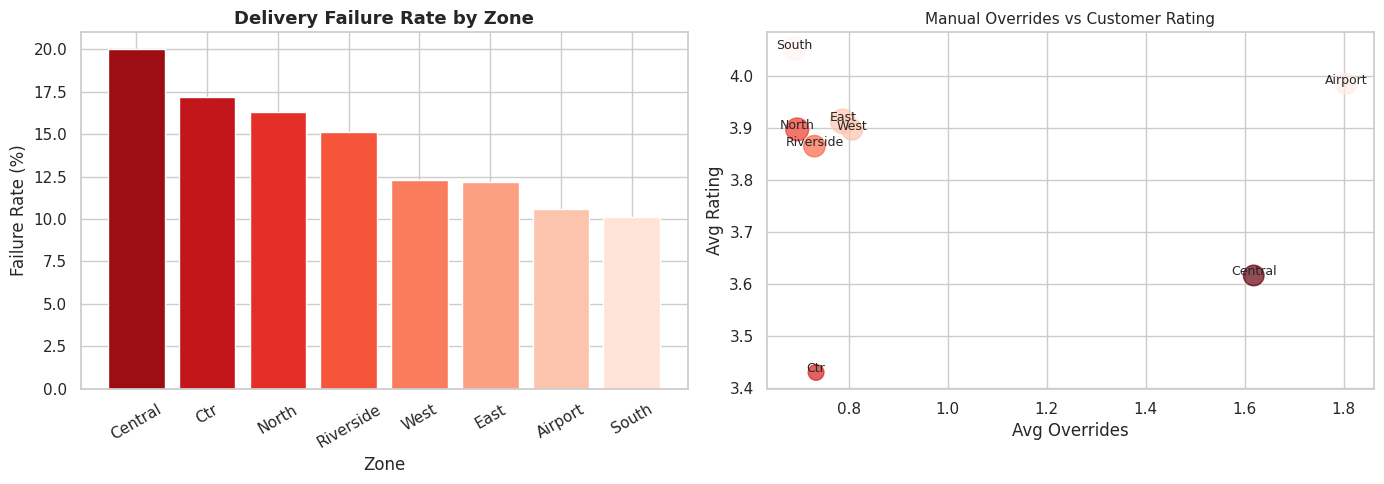

In [ ]:
zone_perf = ops.groupby('pickup_zone').agg(
    total_deliveries  = ('delivery_id','count'),
    failed_deliveries = ('delivery_status', lambda x: (x=='Failed').sum()),
    late_deliveries   = ('delivery_status', lambda x: (x=='Late').sum()),
    avg_rating        = ('customer_rating_post_delivery','mean'),
    avg_overrides     = ('manual_route_override_count','mean')
).reset_index()
zone_perf['failure_rate_%'] = (zone_perf['failed_deliveries']/zone_perf['total_deliveries']*100).round(1)
zone_perf = zone_perf.sort_values('failure_rate_%', ascending=False)
print(zone_perf.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(zone_perf['pickup_zone'], zone_perf['failure_rate_%'],
            color=sns.color_palette('Reds_r', len(zone_perf)))
axes[0].set_title('Delivery Failure Rate by Zone', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Zone'); axes[0].set_ylabel('Failure Rate (%)')
axes[0].tick_params(axis='x', rotation=30)
sc = axes[1].scatter(zone_perf['avg_overrides'], zone_perf['avg_rating'],
                s=zone_perf['total_deliveries']*2, alpha=0.7,
                c=zone_perf['failure_rate_%'], cmap='Reds')
for _, row in zone_perf.iterrows():
    axes[1].annotate(row['pickup_zone'], (row['avg_overrides'], row['avg_rating']), fontsize=9, ha='center')
axes[1].set_title('Manual Overrides vs Customer Rating', fontsize=11)
axes[1].set_xlabel('Avg Overrides'); axes[1].set_ylabel('Avg Rating')
plt.tight_layout(); plt.savefig('fig1_zone_performance.png', dpi=150, bbox_inches='tight'); plt.show()

## 3.3 Analysis 2 - Complaint Patterns

   complaint_type  count  avg_resolution_days  avg_compensation  open_count
            Delay    101             7.257426         18.051489          17
     MissedPickup     64             7.640625         22.593651          12
         AppIssue     53             8.603774         19.614400           8
  DriverBehaviour     51             8.156863         21.153478           9
SupportExperience     20             7.450000         17.125000           4
          Billing     16             7.750000         23.871250           5
           Damage     15            11.333333         23.982000           1


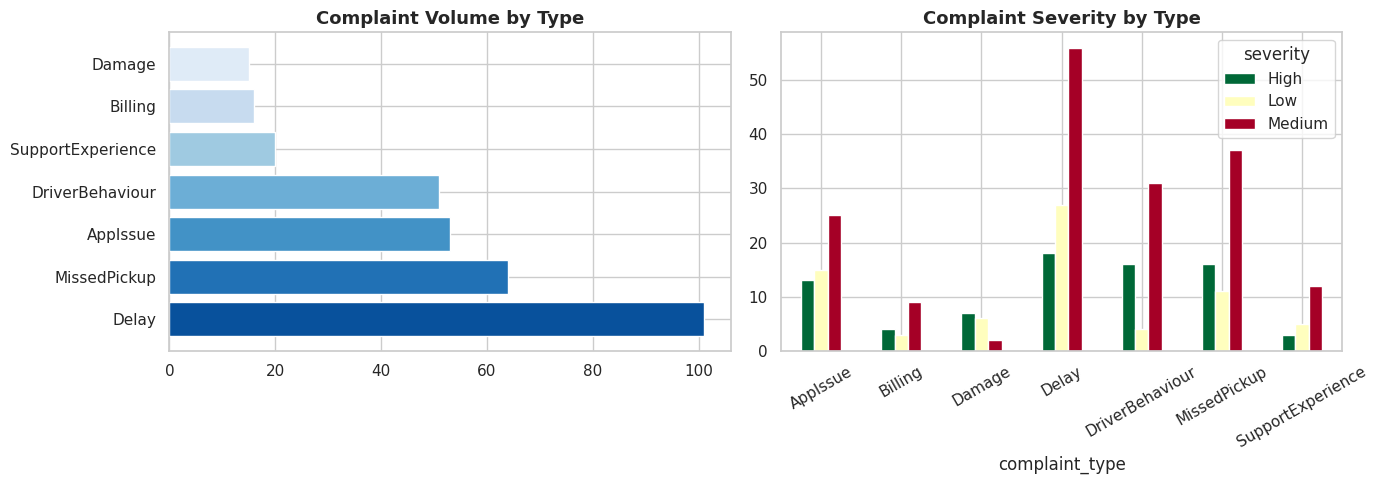

In [ ]:
comp_summary = complaints.groupby('complaint_type').agg(
    count               = ('complaint_id','count'),
    avg_resolution_days = ('resolution_days','mean'),
    avg_compensation    = ('compensation_amount','mean'),
    open_count          = ('status', lambda x: (x=='Open').sum())
).reset_index().sort_values('count', ascending=False)
print(comp_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(comp_summary['complaint_type'], comp_summary['count'],
             color=sns.color_palette('Blues_r', len(comp_summary)))
axes[0].set_title('Complaint Volume by Type', fontsize=13, fontweight='bold')
sev_ct = complaints.groupby(['complaint_type','severity']).size().unstack(fill_value=0)
sev_ct.plot(kind='bar', ax=axes[1], colormap='RdYlGn_r')
axes[1].set_title('Complaint Severity by Type', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.savefig('fig2_complaints.png', dpi=150, bbox_inches='tight'); plt.show()

## 3.4 Analysis 3 - Fleet Health and Incident Risk

Vehicles at risk (battery<60%, incidents>0): 13
vehicle_id  battery_health  odometer_km  incident_count maintenance_status
      V005            58.6       146638               5             Active
      V010            50.7       129032               3           InRepair
      V012            56.2        52021               4             Active
      V025            42.0        52074               4             Active
      V037            56.6        52146               2           InRepair
      V049            55.9        15278               2             Active
      V067            57.3       176145               3             Active
      V084            47.6        53872               3           InRepair
      V087            49.7       116811               1             Active
      V091            58.5       172956               2             Active


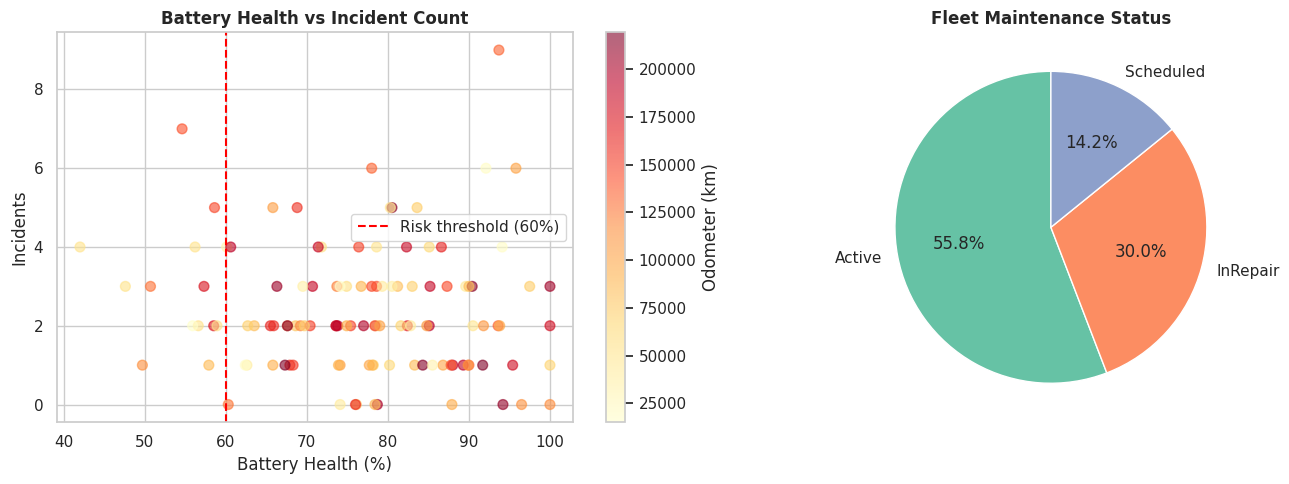

In [ ]:
del_inc = deliveries.merge(incidents, on='delivery_id', how='left').merge(vehicles, on='vehicle_id', how='left')
del_inc['has_incident'] = del_inc['incident_id'].notna().astype(int)
veh_risk = del_inc.groupby('vehicle_id').agg(
    battery_health     = ('battery_health_pct','first'),
    odometer_km        = ('odometer_km','first'),
    incident_count     = ('has_incident','sum'),
    maintenance_status = ('maintenance_status','first')
).dropna(subset=['battery_health']).reset_index()
at_risk = veh_risk[(veh_risk['battery_health'] < 60) & (veh_risk['incident_count'] > 0)]
print(f'Vehicles at risk (battery<60%, incidents>0): {len(at_risk)}')
print(at_risk.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = axes[0].scatter(veh_risk['battery_health'], veh_risk['incident_count'],
                     alpha=0.6, c=veh_risk['odometer_km'], cmap='YlOrRd', s=50)
axes[0].axvline(60, color='red', linestyle='--', label='Risk threshold (60%)')
axes[0].set_title('Battery Health vs Incident Count', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Battery Health (%)'); axes[0].set_ylabel('Incidents'); axes[0].legend()
plt.colorbar(sc, ax=axes[0], label='Odometer (km)')
maint = vehicles['maintenance_status'].value_counts()
axes[1].pie(maint.values, labels=maint.index, autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Set2'))
axes[1].set_title('Fleet Maintenance Status', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('fig3_fleet_health.png', dpi=150, bbox_inches='tight'); plt.show()

3.5 Analysis 4 - Driver Performance vs Training Score

Correlation matrix:
                  training_score  driver_rating  years_experience  \
training_score             1.000         -0.070             0.108   
driver_rating             -0.070          1.000             0.063   
years_experience           0.108          0.063             1.000   
fail_rate_%                0.093         -0.236             0.208   
avg_override              -0.054          0.005            -0.003   

                  fail_rate_%  avg_override  
training_score          0.093        -0.054  
driver_rating          -0.236         0.005  
years_experience        0.208        -0.003  
fail_rate_%             1.000         0.067  
avg_override            0.067         1.000  


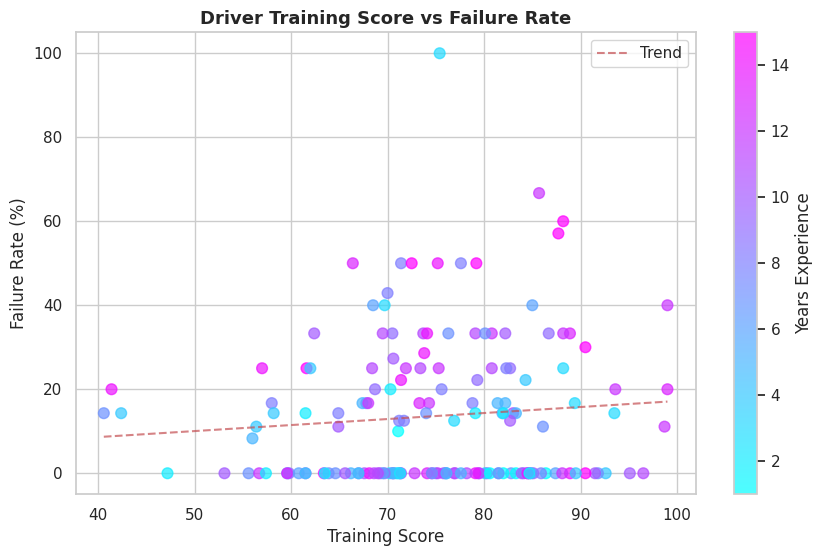

In [ ]:
driver_ops = ops.groupby('driver_id').agg(
    total_jobs   = ('delivery_id','count'),
    failed_jobs  = ('delivery_status', lambda x: (x=='Failed').sum()),
    avg_override = ('manual_route_override_count','mean')
).reset_index()
driver_ops = driver_ops.merge(
    drivers[['driver_id','training_score','driver_rating','employment_type','years_experience']],
    on='driver_id', how='left')
driver_ops['fail_rate_%'] = (driver_ops['failed_jobs']/driver_ops['total_jobs']*100).round(1)

print('Correlation matrix:')
print(driver_ops[['training_score','driver_rating','years_experience','fail_rate_%','avg_override']].corr().round(3))

plot_data = driver_ops[['training_score','fail_rate_%','years_experience']].dropna()

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(plot_data['training_score'], plot_data['fail_rate_%'],
                c=plot_data['years_experience'], cmap='cool', alpha=0.7, s=60)
plt.colorbar(sc, ax=ax, label='Years Experience')

z = np.polyfit(plot_data['training_score'], plot_data['fail_rate_%'], 1)
xs = np.linspace(plot_data['training_score'].min(), plot_data['training_score'].max(), 100)
ax.plot(xs, np.poly1d(z)(xs), 'r--', alpha=0.7, label='Trend')

ax.set_title('Driver Training Score vs Failure Rate', fontsize=13, fontweight='bold')
ax.set_xlabel('Training Score'); ax.set_ylabel('Failure Rate (%)'); ax.legend()
plt.savefig('fig4_driver_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.6 Analysis 5 - Monthly Operational Trends

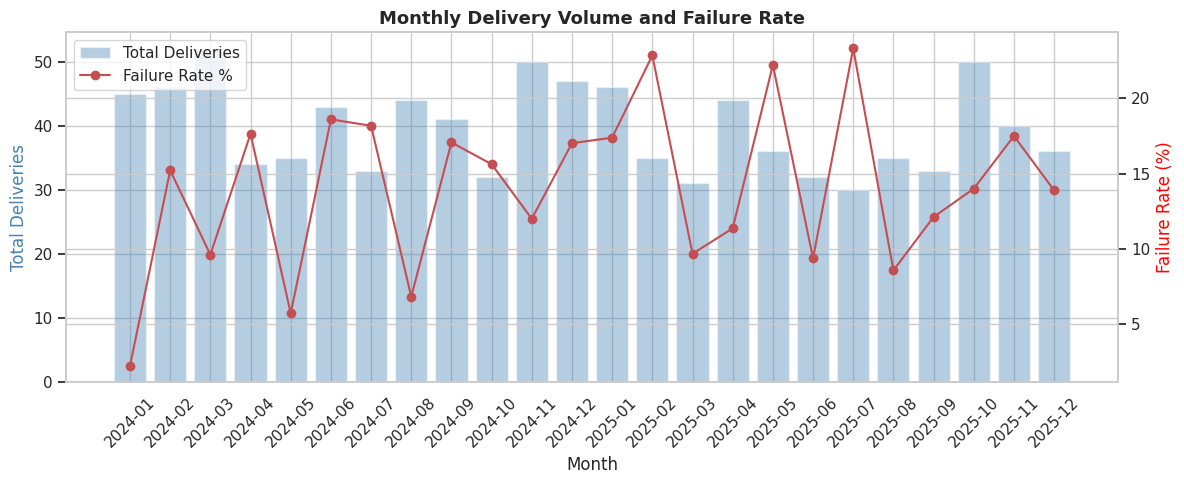

In [ ]:
ops['month'] = ops['dispatch_time'].dt.to_period('M')
monthly = ops.groupby('month').agg(
    total  = ('delivery_id','count'),
    failed = ('delivery_status', lambda x: (x=='Failed').sum())
).reset_index()
monthly['month_str'] = monthly['month'].astype(str)
monthly['fail_rate'] = monthly['failed'] / monthly['total'] * 100

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.bar(monthly['month_str'], monthly['total'], alpha=0.4, color='steelblue', label='Total Deliveries')
ax2.plot(monthly['month_str'], monthly['fail_rate'], 'r-o', label='Failure Rate %')
ax1.set_xlabel('Month'); ax1.set_ylabel('Total Deliveries', color='steelblue')
ax2.set_ylabel('Failure Rate (%)', color='red')
ax1.tick_params(axis='x', rotation=45)
ax1.set_title('Monthly Delivery Volume and Failure Rate', fontsize=13, fontweight='bold')
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc='upper left')
plt.tight_layout(); plt.savefig('fig5_monthly_trends.png', dpi=150, bbox_inches='tight'); plt.show()